In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

#data loading and understanding..

In [3]:
df = pd.read_csv("../data/ibm.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
for col in df.columns:
    print(f'{col} :{df[col].nunique()}')
    # unique values 

customerID :7043
gender :2
SeniorCitizen :2
Partner :2
Dependents :2
tenure :73
PhoneService :2
MultipleLines :3
InternetService :3
OnlineSecurity :3
OnlineBackup :3
DeviceProtection :3
TechSupport :3
StreamingTV :3
StreamingMovies :3
Contract :3
PaperlessBilling :2
PaymentMethod :4
MonthlyCharges :1585
TotalCharges :6531
Churn :2


# data cleaning and preprocessing

In [12]:
df_clean = df.copy()

In [13]:
df_clean["customerID"].head()

0    7590-VHVEG
1    5575-GNVDE
2    3668-QPYBK
3    7795-CFOCW
4    9237-HQITU
Name: customerID, dtype: str

In [14]:
df_clean.drop("customerID",axis=1,inplace=True)
#removing customerID as it unnessary , not any meaning full impact to decide churn.

In [15]:
df_clean.columns
#checking whtether customerid is removed or not.

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [16]:
df_clean.dtypes
# here total charge is represent str ??? because some rows contain blank spaces (" ").preventing pandas recognizing the column as numeric

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [17]:
(df_clean["TotalCharges"]==" ").sum()

np.int64(11)

In [18]:
#conveting total charge to numeric value
df_clean["TotalCharges"]=pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)
# coerce is an option in pandas functions like pd.to_numeric() and pd.to_datetime(). it says if value can't be converted ,don't raise an erro -replace with with NaN or NaT

In [19]:
(df_clean['TotalCharges']=='').sum()

np.int64(0)

In [20]:
df_clean[df_clean['TotalCharges'].isnull()]
#investing the missing rows .

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [21]:
df_clean.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [22]:
df_clean.dropna(inplace=True) 
#dropping that 11 missing values

In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
df_clean.shape
#checking new shape

(7032, 20)

In [25]:
df_clean.info()
#verfying dataset to ensure total charge is appered as float or not 

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

# Exploratory Data analysis..

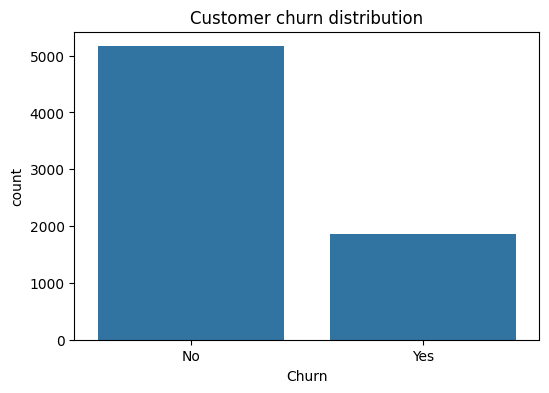

In [26]:
#Q.how many customers leave the company ?
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean ,x="Churn")
plt.title("Customer churn distribution")
plt.show()

this explains most customer stay with the company ,while smaller portion is churn. this indicates that the dataset is slighlty imbalanced ,which should be considered during model evaluation.

In [27]:
df_clean["Churn"].value_counts(normalize=True)*100
# with normalize it gives proportion of No and yes value.

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

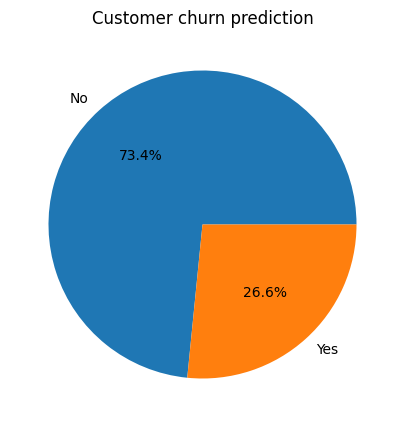

In [28]:
df_clean['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5)
)
plt.title("Customer churn prediction")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

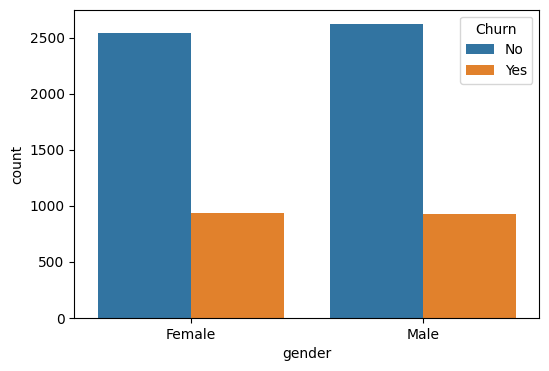

In [29]:
# Gender vs churn
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_clean,
    x="gender",
    hue="Churn"

)
plt.show
#In Seaborn, hue adds another categorical variable by using different colors.

this shows that the male and female customer shows very similar churn behaviour . Gender alone is unlikely to be an impotant predictor ..

<Axes: xlabel='SeniorCitizen', ylabel='count'>

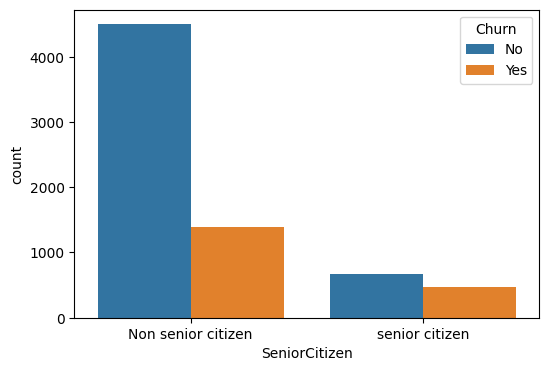

In [30]:
#Senior citizen vs churn
df_clean['SeniorCitizen']=df_clean['SeniorCitizen'].map({
    0:"Non senior citizen",
    1:"senior citizen"
})
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_clean,
    x='SeniorCitizen',
    hue="Churn"
)


senior citizens appear to churn at a higher rate than non-senior customers

<Axes: xlabel='Contract', ylabel='count'>

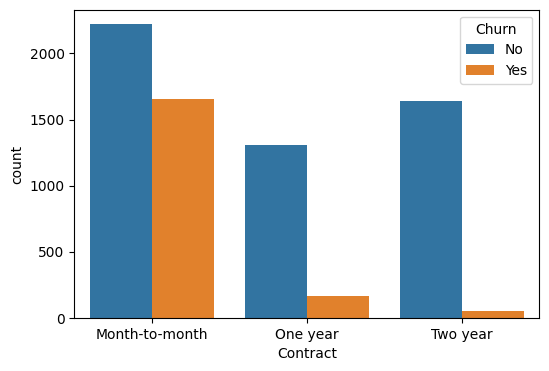

In [31]:
#Contract type vs churn
plt.figure(figsize=(6,4))
sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn"
)

this shows that customers with month-month contracts are much likely to leave,while long-term contracts significantly improve customer relations.

<Axes: xlabel='InternetService', ylabel='count'>

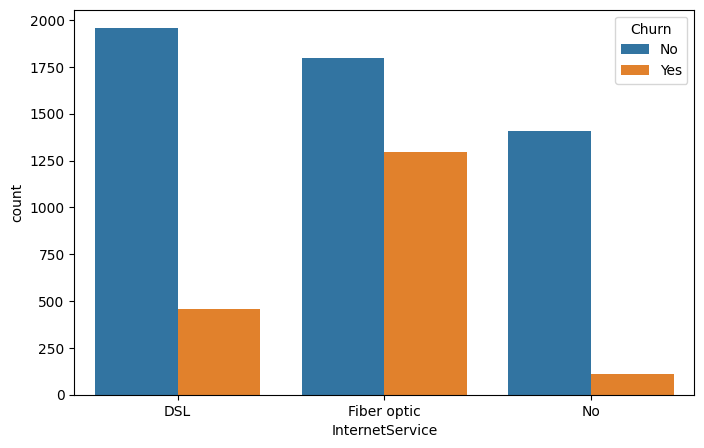

In [32]:
#InternetService vs churn
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_clean,
    x="InternetService",
    hue="Churn"
)

it is observed that fibre optic internet service has highest churn

Text(0.5, 1.0, 'Payment Method vs Churn')

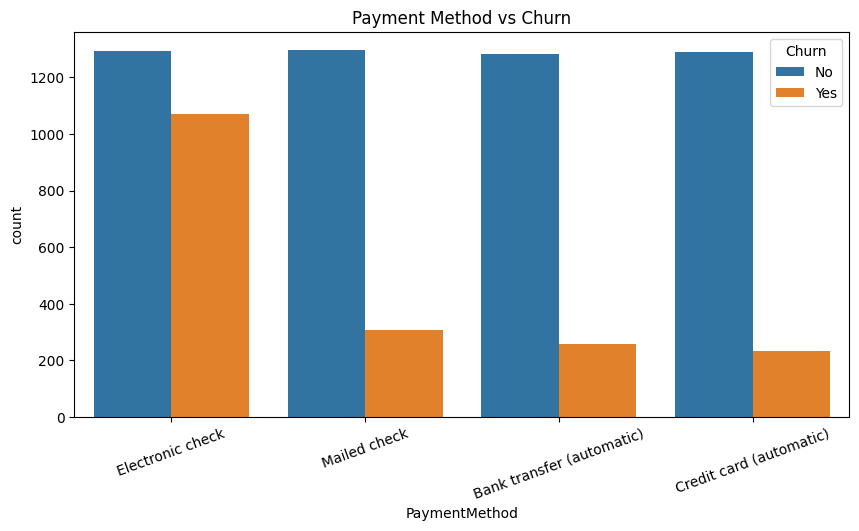

In [33]:
#Payment Method vs Churn
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_clean,
    x="PaymentMethod",
    hue="Churn"
)
plt.xticks(rotation=20)
plt.title("Payment Method vs Churn")

Usually ,Electronic check customers churn more.

<function matplotlib.pyplot.show(close=None, block=None)>

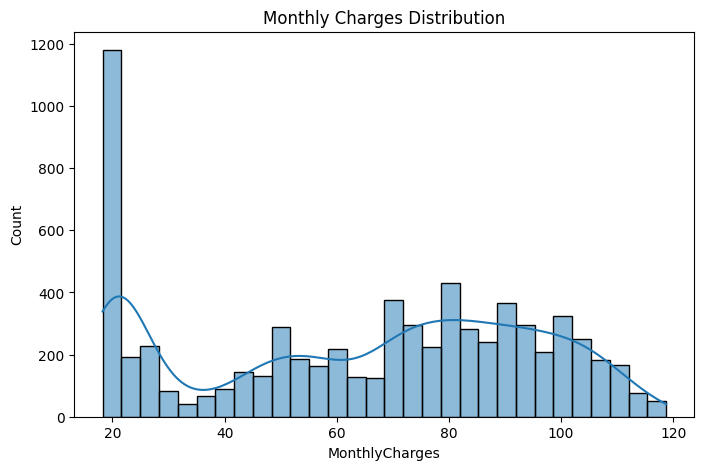

In [34]:
#Monthtly charge Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df_clean["MonthlyCharges"],
    bins=30,
    kde=True

)
plt.title("Monthly Charges Distribution")
plt.show

Text(0.5, 1.0, 'Monthly Charges vs Churn')

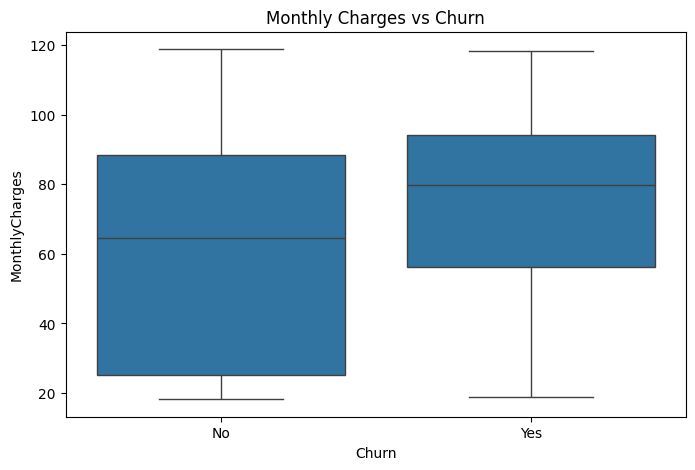

In [35]:
#Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)
plt.title("Monthly Charges vs Churn")

Churn = Yes has a higher median Monthly Charge.
Churn = No has a lower median Monthly Charge.

<function matplotlib.pyplot.show(close=None, block=None)>

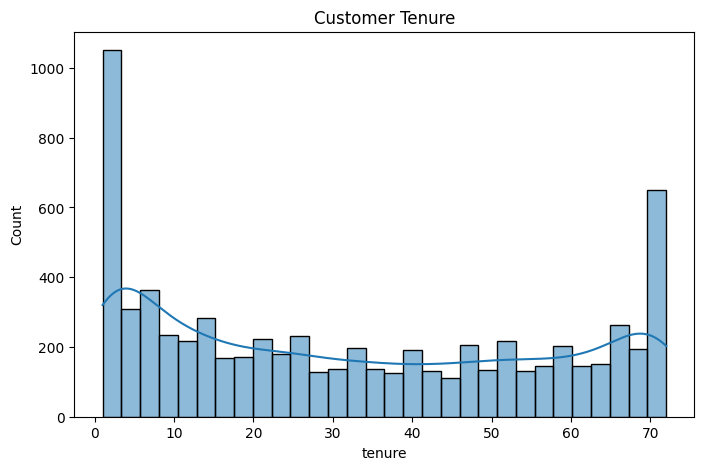

In [36]:
# Tenure Distribution => this shows how long customer stayed with company stayed with company..
plt.figure(figsize=(8,5))
sns.histplot(
    df_clean['tenure'],
    bins=30,
    kde=True
)
plt.title("Customer Tenure")
plt.show

<Axes: xlabel='Churn', ylabel='tenure'>

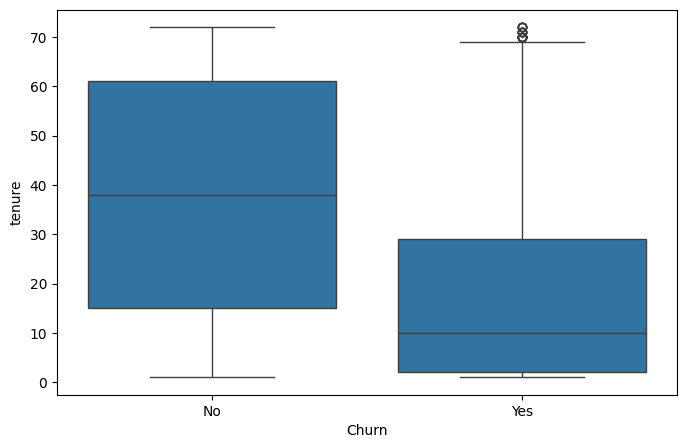

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(
  data =df_clean,
  y='tenure',
  x='Churn'
)

This is one of the strongest predictors.
Customers with short tenure leave much more often.

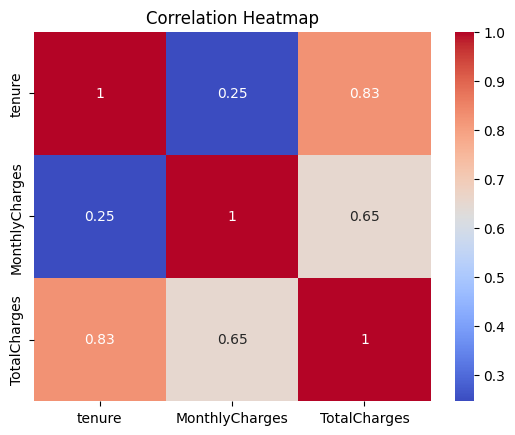

In [38]:
#selecting all the numerical columns..
numeric_df = df_clean.select_dtypes(include=['int64','float64'])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap = "coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering & Data Preprocessing for Machine Learning

In [41]:
#Encode the target variable
df_ml = df_clean.copy()
df_ml['Churn']= df_ml['Churn'].map({
    "Yes":1,
    "No":0
})

In [43]:
df_ml['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [44]:
#Separating the features and target
X= df_ml.drop("Churn",axis=1)
y=df_ml['Churn']

In [45]:
#identyfying Categorical Columns
X.select_dtypes(include="object").columns

C:\Users\acer\AppData\Local\Temp\ipykernel_5948\3716348751.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [46]:
#one hot encoding .
X= pd.get_dummies(
    X,
    drop_first=True
)

In [50]:
X.head()

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_senior citizen,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,False,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,True,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
#training and spliting 
from sklearn.model_selection import train_test_split
X_train , X_test , y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#stratify=y ensures that the training and testing datasets maintain the same class distribution as the original target variable (y